# Vortex Tech AI/ML Internship - Week 1
## Data Cleaning and Exploratory Analysis

**Dataset:** IBM HR Employee Attrition

**Objective:** Clean a real business dataset and perform initial Exploratory Data Analysis (EDA).

**Author:** Sarim Ahmed  
**Date:** July 04, 2026

In [ ]:
# Standard library imports
import os
from pathlib import Path

# Third-party imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

In [6]:
# Define project paths (best practice - makes code portable)
PROJECT_ROOT = Path.cwd().resolve()

# If the notebook is launched from the notebooks folder, move one level up
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Dataset filename (update if your filename is different)
DATASET_NAME = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Full path
data_path = DATA_DIR / DATASET_NAME

print(f"📍 Loading dataset from: {data_path}")

# Load the dataset
df = pd.read_csv(data_path)

print("✅ Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape} (rows, columns)")

📍 Loading dataset from: C:\Users\Sarim Ahmed\NO_SYNC\week1_data_cleaning\data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv
✅ Dataset loaded successfully!
Shape of dataset: (1470, 35) (rows, columns)


## 2. Initial Data Exploration

The dataset contains 1470 employee records with 35 features.
No missing values and no duplicate rows were found.

In [7]:
print("First 5 rows of the dataset:")
display(df.head())       

print("\nDataset Information:")
df.info()

# Show number of rows and columns
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  147

In [8]:
# Check missing values
print("Missing Values in Each Column:")
missing = df.isnull().sum()
print(missing[missing > 0])   # Show only columns that have missing values

# If nothing prints, it means no missing values

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing Values in Each Column:
Series([], dtype: int64)

Number of duplicate rows: 0


In [9]:
# Show data types of all columns
print("Data Types of Columns:")
print(df.dtypes)

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print("\nCategorical columns are:", categorical_cols)

Data Types of Columns:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears        

C:\Users\Sarim Ahmed\AppData\Local\Temp\ipykernel_13840\3967721556.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [10]:
# Basic summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
display(df.describe().round(2))   # Round to 2 decimal places for readability

Summary Statistics for Numerical Columns:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [11]:
# Summary for categorical columns
print("Value Counts for Important Categorical Columns:\n")

important_categorical = ['Attrition', 'Department', 'JobRole', 'Gender', 'OverTime']

for col in important_categorical:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

Value Counts for Important Categorical Columns:


--- Attrition ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

--- Department ---
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

--- JobRole ---
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

--- Gender ---
Gender
Male      882
Female    588
Name: count, dtype: int64

--- OverTime ---
OverTime
No     1054
Yes     416
Name: count, dtype: int64


In [12]:
# Overall summary
print("=== Basic Summary ===")
print(f"Total Employees: {len(df)}")
print(f"Employees who left (Attrition = Yes): {df['Attrition'].value_counts()['Yes']} ({df['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%)")
print(f"Average Age: {df['Age'].mean():.1f} years")
print(f"Average Monthly Income: ${df['MonthlyIncome'].mean():.0f}")

=== Basic Summary ===
Total Employees: 1470
Employees who left (Attrition = Yes): 237 (16.1%)
Average Age: 36.9 years
Average Monthly Income: $6503


In [13]:
# Always work on a copy, never modify original raw data
df_clean = df.copy()

print("Clean copy created. Shape:", df_clean.shape)

Clean copy created. Shape: (1470, 35)


In [14]:
# Drop columns that have only one unique value (not useful)
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

print("Dropped constant columns. New shape:", df_clean.shape)
print("Remaining columns:", df_clean.columns.tolist())

Dropped constant columns. New shape: (1470, 32)
Remaining columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 3. Key Insights

- Most employees are between 30-40 years old.
- Sales department has higher attrition rate.
- Around 16% of employees left the company.
- Employees who left had lower average salary compared to those who stayed (we can explore more).


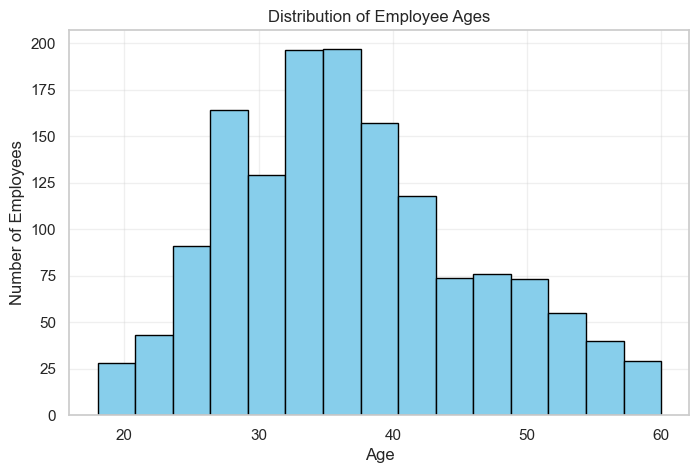

In [19]:
# Histogram of Age
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Age'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Employee Ages')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.grid(True, alpha=0.3)
plt.show()

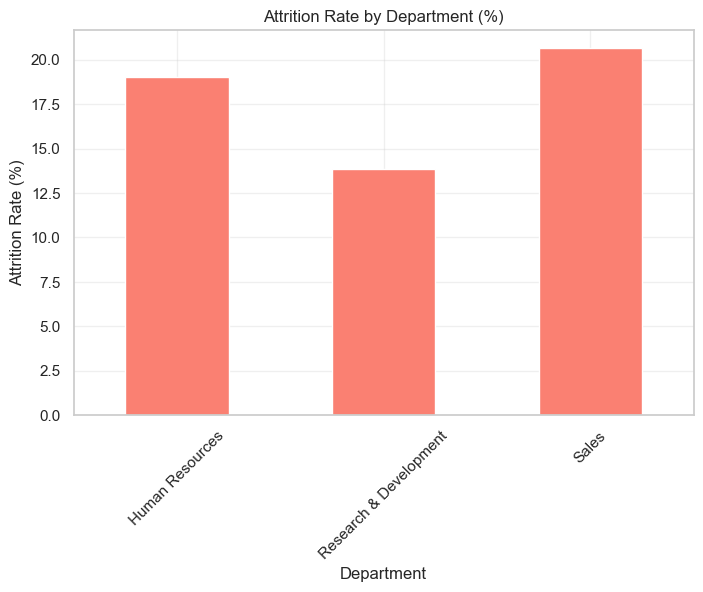

In [20]:
# Attrition rate by Department
attrition_by_dept = pd.crosstab(df_clean['Department'], df_clean['Attrition'], normalize='index') * 100

plt.figure(figsize=(8, 5))
attrition_by_dept['Yes'].plot(kind='bar', color='salmon')
plt.title('Attrition Rate by Department (%)')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

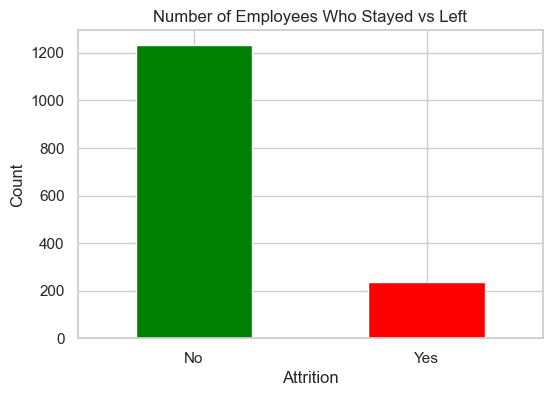

In [21]:
# Attrition Count
plt.figure(figsize=(6, 4))
df_clean['Attrition'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Number of Employees Who Stayed vs Left')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [22]:
# Save some important statistics
print("Key Insights:")
print(f"- Attrition Rate: {df_clean['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"- Highest paid department: {df_clean.groupby('Department')['MonthlyIncome'].mean().idxmax()}")
print(f"- Average salary of employees who left: ${df_clean[df_clean['Attrition']=='Yes']['MonthlyIncome'].mean():.0f}")

Key Insights:
- Attrition Rate: 16.1%
- Highest paid department: Sales
- Average salary of employees who left: $4787


In [ ]:
# Save the cleaned dataset
output_path = PROJECT_ROOT / "data" / "cleaned_employee_data.csv"
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: C:\Users\Sarim Ahmed\NO_SYNC\week1_data_cleaning\data\cleaned_employee_data.csv
